## Reading in Datasets from Kaggle
#### Given the total size of the entire Kaggle Dataset (89GB) capturing 153M QUIC protocol flows *weeks_to_download* variable lets you select which weeks to download

In [ ]:
import math
from os import times

from sklearn.pipeline import FeatureUnion
from tensorflow.python.autograph.pyct.templates import replace

from data_acquisition import Data_acquisition

da = Data_acquisition()

# Specify which weeks to be downloaded
weeks_to_download = ['week_1', 'week_2', 'week_3', 'week_4']

da.download_datasets(weeks_to_download)

### Data Exploration
#### Given the size only one day of data is explored to examine features and their distributions

In [ ]:
import pandas as pd
week1_mon_df = pd.read_csv('./dataset/week_1/mon.csv')
week1_mon_df.head(5)

In [ ]:
week1_mon_df.info()
week1_mon_df.isnull().sum()

#### Class Distribution

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

app_counts = week1_mon_df['APP'].value_counts()


plt.figure(figsize=(14, 20))
sns.barplot(x=app_counts.values, y=app_counts.index)
plt.xscale('log')
plt.xlabel('Flow Count (in log scale)')
plt.ylabel('App Class')
plt.title('Full APP Class Distribution - Log Scale')
plt.tight_layout()
plt.show()

In [ ]:
providers = ['google', 'microsoft', 'facebook','discord', 'instagram', 'apple', 'garmin']
def get_provider(app_name):
    app_lower = str(app_name).lower()
    for provider in providers:
        if provider in app_lower:
            return provider
    return 'other'

app_provider_percentage = (
    app_counts
    .groupby(get_provider)
    .sum()
    .pipe(lambda s: s / s.sum() * 100)
    .round(2)
    .sort_values(ascending=False)
)

plt.figure(figsize=(6, 6))
plt.pie(app_provider_percentage, labels=app_provider_percentage.index, autopct='%1.0f%%')
plt.title('Traffic per Provider')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

category_counts = week1_mon_df['CATEGORY'].value_counts()


plt.figure(figsize=(14, 10))
sns.barplot(x=category_counts.values, y=category_counts.index)
plt.xscale('log')
plt.xlabel('Flow Count (in log scale)')
plt.ylabel('App Class')
plt.title('Category Class Distribution - Log Scale')
plt.tight_layout()
plt.show()

### Dropping Useless Columns prior to Storing in Database to reduce dataset size
#### Cols Dropped and Rational:
##### ID: Identifier column, no predictable signal.
##### SRC_IP/DST_IP: Dropped since although still present post ECH, vary across CDN's and load balancers. Model would memorise IP addresses rather.
##### DST_ASN: Derived from DST_IP and hence is proxy introducing data-leakage.
##### DST_PORT: Consistent, (443) is standard for QUIC.
##### PROTOCOL: Consistent all flows are QUIC-over-UDP.
##### QUIC_VERSION: Extracted from HelloClient Handshake.
##### QUIC_SNI: Extracted from HelloClient Handshake.
##### QUIC_USERAGENT: Derrived from HelloClient Handshake and lots of nulls.
###
#### Cols used for labels
##### APP: Application used (Fine-grained Label)
##### CATEGORY: Type of traffic (Generic Label)

In [1]:
# Drops columns and converts and replaces .csv files with .parquet to increase efficiency and decrease storage requirements
import json


cols_to_drop= ['ID', 'SRC_IP', 'DST_IP', 'DST_ASN', 'SRC_PORT', 'DST_PORT', 'PROTOCOL', 'QUIC_VERSION', 'QUIC_SNI', 'QUIC_USERAGENT']

with open('./config.json', 'w') as f:
    json.dump({'cols_to_drop': cols_to_drop}, f, indent=4)

# Ran as script due to multiprocessing
!python preprocessing.py

### Counting quantity of flows correlating to each 'APP' class in week_1 to establish a suitable maximum and minimum for data sampling
##### max_sampling: Maximum number of unique flows per class allowed in dataset.
##### min_sampling: Minimum flows required for a class to be retained in the dataset. Classes below this threshold are excluded from all splits.

In [2]:
import duckdb
import os

con = duckdb.connect()

week_path_dict = {
    'week_1': './dataset/week_1/*.parquet',
    'week_2': './dataset/week_2/*.parquet',
    'week_3': './dataset/week_3/*.parquet',
    'week_4': './dataset/week_4/*.parquet',
}

week_1_path = week_path_dict['week_1']

counts = con.execute(f"""
    SELECT APP, COUNT(*) as total_flows
    FROM read_parquet('{week_1_path}')
    GROUP BY APP
    ORDER BY total_flows ASC
""").df()

print(counts.to_string())
print(f"\nTotal classes: {len(counts)}")
print(f"Min flows in any class: {counts['total_flows'].min()}")
print(f"Max flows in any class: {counts['total_flows'].max()}")
print(f"Median flows per class: {counts['total_flows'].median()}")

# max_samples: Capped at 5000 â€” 10 classes fall below this naturally and contribute all available flows. Remaining 95 classes are downsampled to 5000.
max_samples = 5_000
# min_samples: Set to the minimum observed class count from Week 1 audit (uber, 1291). All 105 classes are retained â€” no classes are dropped.
min_samples = int(counts['total_flows'].min())

surviving_classes = con.execute(f"""
    SELECT APP
    FROM read_parquet('{week_1_path}')
    GROUP BY APP
    HAVING COUNT(*) >= {min_samples}
""").df()['APP'].tolist()

surviving_classes_sql = ', '.join(f"'{c}'" for c in surviving_classes)
print(f"\nSurviving classes: {len(surviving_classes)}")

                       APP  total_flows
0                     uber         1291
1                livescore         1871
2       ebay-kleinanzeigen         2270
3            alza-identity         2477
4                   fitbit         2637
5                    toggl         2694
6       bitdefender-nimbus         2808
7                   kaggle         3237
8                    dcard         4096
9             overleaf-cdn         4712
10           pocasidata-cz         5005
11                   bitly         5425
12                   4chan         5556
13                  shazam         6544
14                 adavoid         6652
15                 revolut         6880
16                 blogger         9017
17           endnote-click        11635
18                   gmail        12091
19        overleaf-compile        13059
20              signal-cdn        13357
21         google-hangouts        14387
22                   goout        14530
23                tinypass        15177


In [3]:
os.makedirs('./duckdb', exist_ok=True)

for k, v in week_path_dict.items():
    output_path = f'./duckdb/{k}_sampled.parquet'

    con.execute(f"""
        COPY (
            SELECT * EXCLUDE (rn)
            FROM (
                SELECT *,
                       ROW_NUMBER() OVER (
                           PARTITION BY APP
                           ORDER BY RANDOM()
                       ) as rn
                FROM read_parquet('{v}')
                WHERE APP IN ({surviving_classes_sql})
            )
            WHERE rn <= {max_samples}
        ) TO '{output_path}' (FORMAT PARQUET)
    """)

    result = con.execute(f"""
        SELECT APP, COUNT(*) as sampled_flows
        FROM read_parquet('{output_path}')
        GROUP BY APP
        ORDER BY sampled_flows ASC
    """).df()

    print(f"\n--- {k} ---")
    print(f"Classes retained: {len(result)}")
    print(f"Total rows: {result['sampled_flows'].sum()}")
    print(f"Min class: {result.iloc[0]['APP']} ({result.iloc[0]['sampled_flows']} flows)")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


--- week_1 ---
Classes retained: 105
Total rows: 503093
Min class: uber (1291 flows)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


--- week_2 ---
Classes retained: 105
Total rows: 510915
Min class: uber (1718 flows)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


--- week_3 ---
Classes retained: 105
Total rows: 502781
Min class: livescore (731 flows)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


--- week_4 ---
Classes retained: 105
Total rows: 511905
Min class: uber (1743 flows)


### Extracting nested data
##### PPI column contains three nested arrays per row (PPI_TIMES, PPI_DIRS, PPI_SIZES) consisting indices presenting 30 packets each. these are parsed and extracted into individual dataframe features.
##### PHIST columns (PHIST_SRC_SIZES etc...) have a single array per row consisting of 8 histogram bin counts. Each bin represents the number of packets falling within a specific size or inter-packet time range (on a log scale). These are parsed and extracted into individual dataframe features.

In [4]:
import pandas as pd
from feature_engineering import Feature_Engineering

ppi_pad_len = 30
phist_pad_len = 8

def pipeline_parse_cols(fe: Feature_Engineering, df: pd.DataFrame, ppi_pad_len: int, phist_pad_len: int):
    print('Parsing PPI cols')
    fe.parse_col('PPI', ['PPI_TIMES', 'PPI_DIRS', 'PPI_SIZES'])
    fe.parse_col_lists(ppi_pad_len)
    print('Parsing PHIST cols')
    fe.parse_col('PHIST_SRC_SIZES', ['PHIST_SRC_SIZES'])
    fe.parse_col('PHIST_DST_SIZES', ['PHIST_DST_SIZES'])
    fe.parse_col('PHIST_SRC_IPT', ['PHIST_SRC_IPT'])
    fe.parse_col('PHIST_DST_IPT', ['PHIST_DST_IPT'])
    fe.parse_col_lists(phist_pad_len)


#### Encoding and Scalings:
##### Data Exploration below reveals that numerical features are heavily skewed to the right indicating massive outlier ranges, therefore all numerical features were scaled using RobustScaler in order to not destroy these outliers

##### Label features were encoded using label encoder over one hot encoding given the number of additional columns that would need to be created. Dataframes are already massive with lots of features, adding more increases overfitting risk aswell as increased computation during model training.

Parsing PPI cols
Parsing PHIST cols


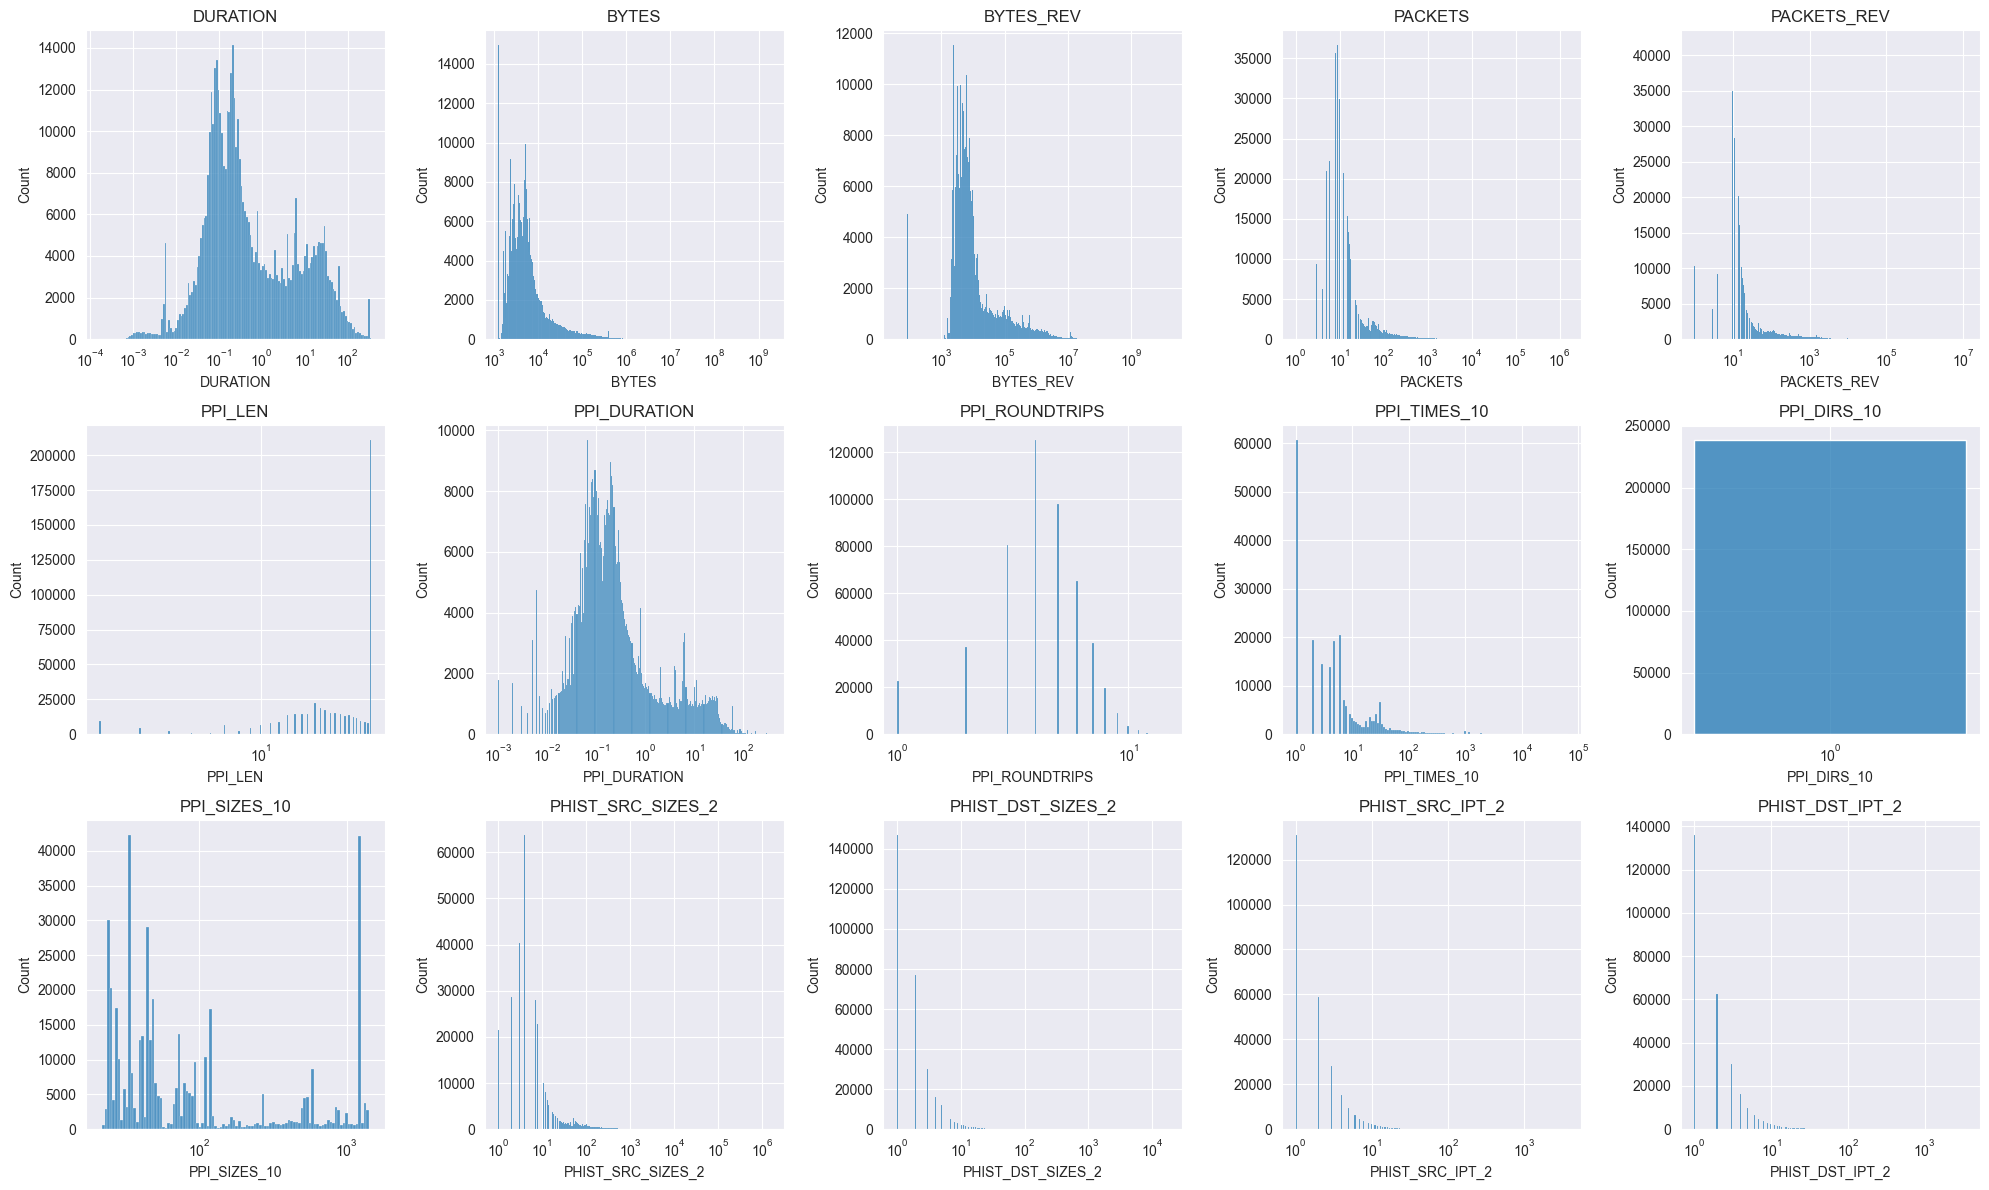

In [5]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
from feature_engineering import Feature_Engineering

sample_week = pd.read_parquet('./duckdb/week_1_sampled.parquet')
fe = Feature_Engineering(sample_week)
pipeline_parse_cols(fe, sample_week, ppi_pad_len, phist_pad_len)
sample_week = fe.get_tabular_dataset()

ppi_sample_packet = math.floor(ppi_pad_len/3)
phist_sample_packet = math.floor(phist_pad_len/3)

numerical_cols = ['DURATION', 'BYTES', 'BYTES_REV', 'PACKETS', 'PACKETS_REV', 'PPI_LEN', 'PPI_DURATION', 'PPI_ROUNDTRIPS', f'PPI_TIMES_{ppi_sample_packet}', f'PPI_DIRS_{ppi_sample_packet}', f'PPI_SIZES_{ppi_sample_packet}', f'PHIST_SRC_SIZES_{phist_sample_packet}', f'PHIST_DST_SIZES_{phist_sample_packet}', f'PHIST_SRC_IPT_{phist_sample_packet}', f'PHIST_DST_IPT_{phist_sample_packet}']

fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(20, 12))
axes = axes.flatten()  # now just a flat list of 15 slots

for i, col in enumerate(numerical_cols):
    sns.histplot(sample_week[col], kde=False, log_scale=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

##### Ostrates the scaling and encoding of each days dataset and saves them to ./tabular_dataset and ./sequential_dataset for ML models to use.

##### - tabular datasets contain all features + labels with PPI and PHIST array indices split into individual columns

##### - sequential datasets contain only PPI's + labels with each PPI as an array

In [6]:
from sklearn.preprocessing import LabelEncoder, RobustScaler
import write_out
from feature_engineering import Feature_Engineering
import pandas as pd
import os

# Storing scaler and encoders for reverse_transform after
re = RobustScaler()
encoders_dict = {'label_encoder': {},
                 'RobustScaler': re}

for file in sorted(os.listdir('./duckdb')):
    if file.endswith('.parquet'):
        file_path = os.path.join('./duckdb', file)
        df = pd.read_parquet(file_path)
        print(f'{file}: {df.shape}')

        fe = Feature_Engineering(df)
        pipeline_parse_cols(fe, df, ppi_pad_len, phist_pad_len)

        is_week_1 =  "week_1" in file
        fe.perform_encode_and_scaling(encoders_dict, is_week_1)

        tabular_df = fe.get_tabular_dataset()
        write_out.write_out_tabular(tabular_df, file)


week_1_sampled.parquet: (503093, 20)
Parsing PPI cols
Parsing PHIST cols
Label Encoding...
Robust Scaling...
Merging final df
TABULAR_DATASET_PATH: ./tabular_dataset/tabular_week_1_sampled.parquet
tabular_week_1_sampled.parquet: (503093, 135) saved to ./tabular_dataset/tabular_week_1_sampled.parquet
week_2_sampled.parquet: (510915, 20)
Parsing PPI cols
Parsing PHIST cols
Label Encoding...
Robust Scaling...
Merging final df
TABULAR_DATASET_PATH: ./tabular_dataset/tabular_week_2_sampled.parquet
tabular_week_2_sampled.parquet: (510915, 135) saved to ./tabular_dataset/tabular_week_2_sampled.parquet
week_3_sampled.parquet: (502781, 20)
Parsing PPI cols
Parsing PHIST cols
Label Encoding...
Robust Scaling...
Merging final df
TABULAR_DATASET_PATH: ./tabular_dataset/tabular_week_3_sampled.parquet
tabular_week_3_sampled.parquet: (502781, 135) saved to ./tabular_dataset/tabular_week_3_sampled.parquet
week_4_sampled.parquet: (511905, 20)
Parsing PPI cols
Parsing PHIST cols
Label Encoding...
Robust

### Datasets
- **Tabular with PPI** â€” Flow stats + PHIST + PPI summary features (`PPI_LEN`, `PPI_DURATION`, `PPI_ROUNDTRIPS`)
- **Sequential PPI only** â€” Raw PPI sequences only in sequential format

In [23]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

tab_training_path = './tabular_dataset/tabular_week_1_sampled.parquet'
training_df = pd.read_parquet(tab_training_path)

flow_features = ['DURATION', 'BYTES', 'BYTES_REV', 'PACKETS', 'PACKETS_REV']
endreason_features = ['FLOW_ENDREASON_IDLE', 'FLOW_ENDREASON_ACTIVE', 'FLOW_ENDREASON_OTHER']
phist_features = [col for col in training_df if col.startswith('PHIST_')]
ppi_summary_features = ['PPI_LEN', 'PPI_DURATION', 'PPI_ROUNDTRIPS']
ppi_sequence_features = [col for col in training_df if col.startswith('PPI_') and col not in ppi_summary_features]

# Tabular with PPI Dataframe
tab_with_ppi = training_df[flow_features + phist_features + endreason_features + ppi_summary_features]
#print('Tabular with PPI Dataset Columns: ' + str(tab_with_ppi.columns))

# Sequential PPI only Dataframe
ppi_seq_only = training_df[ppi_sequence_features]
#print('PPI Sequential Only Dataset Columns: ' + str(ppi_seq_only.columns))

# Datasets for best model training/validation
best_model_y = training_df['APP']
best_model_X = training_df[flow_features + phist_features + endreason_features + ppi_summary_features + ppi_sequence_features]

bm_X_train, bm_X_test, bm_y_train, bm_y_test = train_test_split(best_model_X, best_model_y, test_size=0.3, random_state=42, stratify=best_model_y)

# Tabular
tab_bm_X_train = bm_X_train.drop(columns=ppi_sequence_features)
tab_bm_X_test  = bm_X_test.drop(columns=ppi_sequence_features)
tab_bm_y_train = bm_y_train
tab_bm_y_test = bm_y_test

# Sequence

def get_x_np_stacks() -> np.ndarray:
    seq_len = 30

    # For X train
    temp_train_df = bm_X_train.drop(columns=tab_cols)
    times = temp_train_df[[f'PPI_TIMES_{i}' for i in range(seq_len)]].values
    sizes = temp_train_df[[f'PPI_SIZES_{i}' for i in range(seq_len)]].values
    dirs = temp_train_df[[f'PPI_DIRS_{i}' for i in range(seq_len)]].values
    seq_X_train = np.stack([times, sizes, dirs], axis=2)  # (n, 30, 3)

    # For X test
    temp_test_df = bm_X_test.drop(columns=tab_cols)
    times = temp_test_df[[f'PPI_TIMES_{i}' for i in range(seq_len)]].values
    sizes = temp_test_df[[f'PPI_SIZES_{i}' for i in range(seq_len)]].values
    dirs = temp_test_df[[f'PPI_DIRS_{i}' for i in range(seq_len)]].values
    seq_X_test = np.stack([times, sizes, dirs], axis=2)  # (n, 30, 3)
    return seq_X_train, seq_X_test



tab_cols = flow_features + phist_features + endreason_features + ppi_summary_features
seq_bm_X_train, seq_bm_X_test = get_x_np_stacks()
seq_bm_y_train = bm_y_train.values
seq_bm_y_test = bm_y_test.values

### Random Forest: Flow Features and PPI Summaries
- **DURATION**
- **BYTES**
- **BYTES_REV**
- **PACKETS**
- **PACKET_REV**
- **PHIST_SRC_SIZES / PHIST_DST_SIZES**
- **PHIST_SRC_IPT / PHIST_DST_IPT**
- **FLOW_ENDREASON_ACTIVE / FLOW_ENDREASON_OTHER / FLOW_ENDREASON_IDLE**
- **PPI_LEN, PPI_DURATION, PPI_ROUNDTRIP**

### Random Forest: Hypertuning Parameters
#### 20% Sample Test

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
import optuna
import gc
from sklearn.ensemble import RandomForestClassifier

y = training_df["APP"]
X = tab_with_ppi
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 20% subsample given computational constraint
X_subsample, _, y_subsample, _ = train_test_split(
    X_train, y_train, train_size=0.20, random_state=42, stratify=y_train
)
X_sub_tr, X_sub_test, y_sub_tr, y_sub_test = train_test_split(
    X_subsample, y_subsample, test_size=0.15, random_state=42, stratify=y_subsample
)

def objective_rf(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 100, 500, step=100),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3, 0.5, 0.7]),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 20),
        max_depth=trial.suggest_int("max_depth", 10, 50),
        max_samples=trial.suggest_float("max_samples", 0.5, 1.0),
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    )
    model = RandomForestClassifier(**params)
    model.fit(X_sub_tr, y_sub_tr)
    score = f1_score(y_sub_test, model.predict(X_sub_test), average="macro")
    del model
    gc.collect()
    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective_rf, n_trials=50, timeout=1200)

print(f"Completed {len(study.trials)} trials")
print("Best params:", study.best_params)
print("Best val F1:", study.best_value)

Index(['DURATION', 'BYTES', 'BYTES_REV', 'PACKETS', 'PACKETS_REV',
       'PHIST_SRC_SIZES_0', 'PHIST_SRC_SIZES_1', 'PHIST_SRC_SIZES_2',
       'PHIST_SRC_SIZES_3', 'PHIST_SRC_SIZES_4', 'PHIST_SRC_SIZES_5',
       'PHIST_SRC_SIZES_6', 'PHIST_SRC_SIZES_7', 'PHIST_DST_SIZES_0',
       'PHIST_DST_SIZES_1', 'PHIST_DST_SIZES_2', 'PHIST_DST_SIZES_3',
       'PHIST_DST_SIZES_4', 'PHIST_DST_SIZES_5', 'PHIST_DST_SIZES_6',
       'PHIST_DST_SIZES_7', 'PHIST_SRC_IPT_0', 'PHIST_SRC_IPT_1',
       'PHIST_SRC_IPT_2', 'PHIST_SRC_IPT_3', 'PHIST_SRC_IPT_4',
       'PHIST_SRC_IPT_5', 'PHIST_SRC_IPT_6', 'PHIST_SRC_IPT_7',
       'PHIST_DST_IPT_0', 'PHIST_DST_IPT_1', 'PHIST_DST_IPT_2',
       'PHIST_DST_IPT_3', 'PHIST_DST_IPT_4', 'PHIST_DST_IPT_5',
       'PHIST_DST_IPT_6', 'PHIST_DST_IPT_7', 'FLOW_ENDREASON_IDLE',
       'FLOW_ENDREASON_ACTIVE', 'FLOW_ENDREASON_OTHER', 'PPI_LEN',
       'PPI_DURATION', 'PPI_ROUNDTRIPS'],
      dtype='str')


[I 2026-04-16 16:52:44,380] A new study created in memory with name: no-name-c5514fb1-08ce-41a1-9648-aa508e04d7e6
[I 2026-04-16 16:52:52,289] Trial 0 finished with value: 0.599831473368124 and parameters: {'n_estimators': 500, 'max_features': 'log2', 'min_samples_leaf': 4, 'max_depth': 13, 'max_samples': 0.8840977490709291}. Best is trial 0 with value: 0.599831473368124.
[W 2026-04-16 16:52:56,261] Trial 1 failed with parameters: {'n_estimators': 400, 'max_features': 'sqrt', 'min_samples_leaf': 11, 'max_depth': 29, 'max_samples': 0.8460111986271383} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "C:\Users\shane\Desktop\111_MSc_AI_Course\.venv1\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\shane\AppData\Local\Temp\ipykernel_10852\2401760469.py", line 32, in objective_rf
    model.fit(X_sub_tr, y_sub_tr)
  File "C:\Users\shane\Deskto

KeyboardInterrupt: 

#### 50% Sample Test

In [9]:
y = training_df["APP"]
X = tab_with_ppi

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 40% subsample given computational constraint
X_subsample, _, y_subsample, _ = train_test_split(
    X_train, y_train, train_size=0.5, random_state=42, stratify=y_train
)
X_sub_tr, X_sub_test, y_sub_tr, y_sub_test = train_test_split(
    X_subsample, y_subsample, test_size=0.15, random_state=42, stratify=y_subsample
)

# Pull top 5 trials from Stage 1 by value
top_trials = sorted(study.trials, key=lambda t: t.value, reverse=True)[:5]

results = []
for trial in top_trials:
    params = trial.params
    model = RandomForestClassifier(
        **params,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_sub_tr, y_sub_tr)
    score = f1_score(y_sub_test, model.predict(X_sub_test), average="macro")
    results.append((score, trial.number, params))  # don't keep fitted model
    del model  # free immediately
    print(f"Trial {trial.number:>3} | Stage1 F1: {trial.value:.4f} | Stage2 F1: {score:.4f}")

# Best confirmed params
best_score, best_trial_num, best_params = max(results, key=lambda x: x[0])
print(f"\nBest confirmed: Trial {best_trial_num} — Stage2 F1: {best_score:.4f}")
print("Params:", best_params)

Trial  47 | Stage1 F1: 0.7058 | Stage2 F1: 0.7393
Trial  48 | Stage1 F1: 0.7055 | Stage2 F1: 0.7395
Trial  37 | Stage1 F1: 0.7035 | Stage2 F1: 0.7384
Trial  35 | Stage1 F1: 0.7020 | Stage2 F1: 0.7369
Trial  41 | Stage1 F1: 0.7018 | Stage2 F1: 0.7391

Best confirmed: Trial 48 — Stage2 F1: 0.7395
Params: {'n_estimators': 400, 'max_features': 0.5, 'min_samples_leaf': 2, 'max_depth': 30, 'max_samples': 0.9774007432283167}


#### Best Random Forest Model Training on Week 1

In [18]:
import gc

# Free stage-2 screening models before the full fit
del results
gc.collect()

rf = RandomForestClassifier(
    **best_params,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1,
)
rf.fit(tab_bm_X_train, tab_bm_y_train)

y_pred = rf.predict(tab_bm_X_test)

# Macro F1 — your primary metric
f1 = f1_score(tab_bm_y_test, y_pred, average='macro')
print(f'Macro F1: {f1:.4f}')

# Full breakdown per class
print(classification_report(tab_bm_y_test, y_pred, zero_division=0))

NameError: name 'results' is not defined

#### Best Random Forest Prediction: Week 2, Week 3 and Week 4

In [11]:
import numpy as np

weeks_to_test = {
    'week_2': './tabular_dataset/tabular_week_2_sampled.parquet',
    'week_3': './tabular_dataset/tabular_week_3_sampled.parquet',
    'week_4': './tabular_dataset/tabular_week_4_sampled.parquet',
}

BATCH = 10_000

for week, path in weeks_to_test.items():
    current_week_df = pd.read_parquet(path)
    X = current_week_df[flow_features + phist_features + endreason_features + ppi_summary_features]
    y = current_week_df['APP']

    preds = []
    for start in range(0, len(X), BATCH):
        preds.append(rf.predict(X.iloc[start:start + BATCH]))
    y_pred = np.concatenate(preds)

    f1 = f1_score(y, y_pred, average='macro')
    print(f'---------------- {week} Results ----------------')
    print(f'Macro F1: {f1:.4f}')

    print(classification_report(y, y_pred, zero_division=0))
    print(f'------------------------------------------------')


---------------- week_2 Results ----------------
Macro F1: 0.7400
              precision    recall  f1-score   support

           0       0.62      0.71      0.66      5000
           1       0.83      0.81      0.82      5000
           2       0.75      0.70      0.73      2730
           3       0.83      0.80      0.81      5000
           4       0.53      0.55      0.54      5000
           5       0.97      0.99      0.98      5000
           6       0.87      0.88      0.87      4128
           7       0.85      0.84      0.85      5000
           8       0.81      0.77      0.79      5000
           9       0.51      0.61      0.55      5000
          10       0.87      0.88      0.88      5000
          11       0.58      0.43      0.50      5000
          12       0.96      0.92      0.94      5000
          13       0.53      0.60      0.56      5000
          14       0.70      0.74      0.72      5000
          15       0.99      0.98      0.98      5000
          16   

### Lightgbm: Hypertuning Parameters
#### 20% Sample Test

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
import optuna
import lightgbm as lgb

y = training_df["APP"]
X = tab_with_ppi

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 10% subsample given computational constraint
X_subsample, _, y_subsample, _ = train_test_split(
    X_train, y_train, train_size=0.20, random_state=42, stratify=y_train
)
X_sub_tr, X_sub_test, y_sub_tr, y_sub_test = train_test_split(
    X_subsample, y_subsample, test_size=0.15, random_state=42, stratify=y_subsample
)

def objective_lightgbm(trial):
    params = dict(
        n_estimators=100,
        num_leaves=trial.suggest_int("num_leaves", 31, 127),
        learning_rate=trial.suggest_float("learning_rate", 0.02, 0.1, log=True),
        min_child_samples=trial.suggest_int("min_child_samples", 5, 30),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        subsample_freq=1,
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-2, 10.0, log=True),
        max_bin=255,
        force_col_wise=True,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_sub_tr, y_sub_tr,
        eval_set=[(X_sub_test, y_sub_test)],
        callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(-1)], # Preventing overfitting on test data by later rounds
    )
    return f1_score(y_sub_test, model.predict(X_sub_test), average="macro")

study = optuna.create_study(direction="maximize")
study.optimize(objective_lightgbm, n_trials=50, timeout=1200)

print(f"Completed {len(study.trials)} trials")
print("Best params:", study.best_params)
print("Best val F1:", study.best_value)


[I 2026-04-16 18:28:31,334] A new study created in memory with name: no-name-2b8c7751-d361-43a4-a342-cd1cf8f8f16e
[I 2026-04-16 18:32:10,875] Trial 0 finished with value: 0.6894568762475489 and parameters: {'num_leaves': 68, 'learning_rate': 0.07311957187001857, 'min_child_samples': 29, 'subsample': 0.6980400927586061, 'colsample_bytree': 0.8609890478651161, 'reg_lambda': 0.025169692147878186}. Best is trial 0 with value: 0.6894568762475489.


#### 50% Sample Test

In [13]:
y = training_df["APP"]
X = tab_with_ppi

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 40% subsample given computational constraint
X_subsample, _, y_subsample, _ = train_test_split(
    X_train, y_train, train_size=0.50, random_state=42, stratify=y_train
)
X_sub_tr, X_sub_test, y_sub_tr, y_sub_test = train_test_split(
    X_subsample, y_subsample, test_size=0.15, random_state=42, stratify=y_subsample
)

# Pull top 5 trials from Stage 1 by value
top_trials = sorted(study.trials, key=lambda t: t.value, reverse=True)[:5]

results = []
for trial in top_trials:
    params = trial.params
    model = lgb.LGBMClassifier(
        **params,
        n_estimators=200,
        max_bin=255,
        force_col_wise=True,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
    model.fit(
        X_sub_tr, y_sub_tr,
        eval_set=[(X_sub_test, y_sub_test)],
        callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)],
    )
    score = f1_score(y_sub_test, model.predict(X_sub_test), average="macro")
    results.append((score, trial.number, params, model))
    print(f"Trial {trial.number:>3} | Stage1 F1: {trial.value:.4f} | Stage2 F1: {score:.4f}")

# Best confirmed params
best_score, best_trial_num, best_params, best_model = max(results, key=lambda x: x[0])
print(f"\nBest confirmed: Trial {best_trial_num} — Stage2 F1: {best_score:.4f}")
print("Params:", best_params)

Trial   6 | Stage1 F1: 0.7062 | Stage2 F1: 0.7433
Trial  14 | Stage1 F1: 0.7061 | Stage2 F1: 0.7458
Trial  16 | Stage1 F1: 0.7056 | Stage2 F1: 0.7461
Trial   7 | Stage1 F1: 0.7044 | Stage2 F1: 0.7464
Trial   5 | Stage1 F1: 0.7043 | Stage2 F1: 0.7408

Best confirmed: Trial 7 — Stage2 F1: 0.7464
Params: {'num_leaves': 118, 'learning_rate': 0.03306378571984226, 'min_child_samples': 16, 'subsample': 0.6908203130996584, 'colsample_bytree': 0.8810053204062163, 'reg_lambda': 0.3295084975115534}


#### Best Light GBM Model Training on Week 1

In [43]:
lightgbm = lgb.LGBMClassifier(
      **best_params,
      n_estimators=500,
      max_bin=255,
      force_col_wise=True,
      class_weight="balanced",
      random_state=42,
      n_jobs=-1,
      verbose=-1,
  )
lightgbm.fit(
      tab_bm_X_train, tab_bm_y_train,
      eval_set=[(tab_bm_X_test, tab_bm_y_test)],
      callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
  )

y_pred = lightgbm.predict(tab_bm_X_test)

# Macro F1 â€” your primary metric
f1 = f1_score(tab_bm_y_test, y_pred, average='macro')
print(f'Macro F1: {f1:.4f}')

# Full breakdown per class
print(classification_report(tab_bm_y_test, y_pred, zero_division=0))

NameError: name 'lgb' is not defined

#### Best Light GBM Model Prediction: Week 2, Week 3 and Week 4

In [15]:
weeks_to_test = {
    'week_2': './tabular_dataset/tabular_week_2_sampled.parquet',
    'week_3': './tabular_dataset/tabular_week_3_sampled.parquet',
    'week_4': './tabular_dataset/tabular_week_4_sampled.parquet',
}

for week, path in weeks_to_test.items():
    current_week_df = pd.read_parquet(path)
    X = current_week_df[flow_features + phist_features + endreason_features + ppi_summary_features]
    y = current_week_df['APP']
    y_pred = lightgbm.predict(X)

    f1 = f1_score(y, y_pred, average='macro')
    print(f'---------------- {week} Results ----------------')
    print(f'Macro F1: {f1:.4f}')

    print(classification_report(y, y_pred, zero_division=0))
    print(f'------------------------------------------------')


---------------- week_2 Results ----------------
Macro F1: 0.7521
              precision    recall  f1-score   support

           0       0.66      0.68      0.67      5000
           1       0.84      0.80      0.82      5000
           2       0.67      0.68      0.68      2730
           3       0.84      0.78      0.81      5000
           4       0.54      0.59      0.56      5000
           5       0.99      0.99      0.99      5000
           6       0.93      0.88      0.90      4128
           7       0.88      0.85      0.86      5000
           8       0.84      0.78      0.81      5000
           9       0.56      0.63      0.60      5000
          10       0.92      0.87      0.90      5000
          11       0.52      0.51      0.51      5000
          12       0.98      0.94      0.96      5000
          13       0.48      0.61      0.54      5000
          14       0.68      0.72      0.70      5000
          15       0.99      0.99      0.99      5000
          16   

### Pure GRU: HyperParameter Tuning

In [25]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

torch.set_float32_matmul_precision('medium')

##### Data preparation for GRU

In [34]:
seq_len = 30
num_features = 3

times = ppi_seq_only[[f'PPI_TIMES_{i}' for i in range(seq_len)]].values
sizes = ppi_seq_only[[f'PPI_SIZES_{i}' for i in range(seq_len)]].values
dirs  = ppi_seq_only[[f'PPI_DIRS_{i}' for i in range(seq_len)]].values

X = np.stack([times, sizes, dirs], axis=2)  # (n, 30, 3)

y = training_df['APP'].values
num_classes = len(np.unique(y))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)


#### 50% Sample Test

In [35]:
X_train, _, y_train, _ = train_test_split(
    X_train, y_train, train_size=0.50, random_state=42, stratify=y_train)

X_tr, X_val, y_tr, y_val = train_test_split(
      X_train, y_train, test_size=0.20, random_state=42, stratify=y_train)

In [36]:
# Creates TensorDataset from X and Y and loads into DataLoader
def to_loader(X, y, batch_size=256, shuffle=False):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32),
                       torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = to_loader(X_tr,  y_tr,  shuffle=True)
val_loader   = to_loader(X_val, y_val)

In [37]:
import optuna
import lightning as L
from lightning.pytorch.callbacks import EarlyStopping

def objective_gru(trial):
    hidden_size    = trial.suggest_int("hidden_size", 32, 256, step=32)
    learning_rate  = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    dropout        = trial.suggest_float("dropout", 0.1, 0.5)
    batch_size     = trial.suggest_categorical("batch_size", [128, 256, 512])

    train_loader_s1 = to_loader(X_tr, y_tr, batch_size=batch_size, shuffle=True)
    val_loader_s2   = to_loader(X_val, y_val, batch_size=batch_size)

    class GRUTrial(L.LightningModule):
        def __init__(self):
            # Layers defined here
            super().__init__()
            self.gru     = nn.GRU(num_features, hidden_size, batch_first=True)
            self.drop    = nn.Dropout(dropout)
            self.fc1     = nn.Linear(hidden_size, 64)
            self.fc2     = nn.Linear(64, num_classes)
            self.loss_fn = nn.CrossEntropyLoss()

        def forward(self, x):
            out, _ = self.gru(x)
            out = self.drop(out[:, -1, :])
            out = self.drop(torch.relu(self.fc1(out)))
            return self.fc2(out)

        def training_step(self, batch, _):
            x, y = batch
            loss = self.loss_fn(self(x), y)
            self.log("train_loss", loss)
            return loss

        def validation_step(self, batch, _):
            x, y = batch
            preds = self(x)
            loss  = self.loss_fn(preds, y)
            acc   = (preds.argmax(1) == y).float().mean()
            self.log_dict({"val_loss": loss, "val_acc": acc})

        def configure_optimizers(self):
            return torch.optim.Adam(self.parameters(), lr=learning_rate)

    model   = GRUTrial()
    trainer = L.Trainer(
        max_epochs=15,
        accelerator="gpu",
        devices=1,
        enable_progress_bar=False,  # cleaner optuna output
        enable_model_summary=False,
        callbacks=[EarlyStopping(monitor="val_loss", patience=3)],
    )
    trainer.fit(model, train_loader_s1, val_loader_s2)

    return trainer.logged_metrics["val_acc"].item()

study = optuna.create_study(direction="maximize")
study.optimize(objective_gru, n_trials=20, timeout=1200)

print("Best params:", study.best_params)
print("Best val acc:", study.best_value)


[I 2026-04-16 17:37:42,087] A new study created in memory with name: no-name-ef427a9e-a313-4a45-968c-4490bc1c9c0a
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
C:\Users\shane\Desktop\111_MSc_AI_Course\.venv1\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
C:\

Best params: {'hidden_size': 192, 'learning_rate': 0.002430936901183005, 'dropout': 0.4771683268732608, 'batch_size': 256}
Best val acc: 0.6490331292152405


#### GRU Best Model on Week 1

In [38]:
# Creates TensorDataset from X and Y and loads into DataLoader
def to_loader(X, y, batch_size=256, shuffle=False):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32),
                       torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = to_loader(seq_bm_X_train,  seq_bm_y_train,  shuffle=True)
val_loader   = to_loader(seq_bm_X_test, seq_bm_y_test)

In [39]:
import lightning as L
from lightning.pytorch.callbacks import EarlyStopping

class GRU(L.LightningModule):
    def __init__(self, num_classes, hidden_size=128, dropout=0.10123525771214088, learning_rate=1e-3):
        super().__init__()
        self.learning_rate = learning_rate
        self.gru     = nn.GRU(3, hidden_size, batch_first=True)
        self.drop    = nn.Dropout(p=dropout)
        self.fc1     = nn.Linear(hidden_size, 64)
        self.fc2     = nn.Linear(64, num_classes)
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.drop(out[:, -1, :])
        out = self.drop(torch.relu(self.fc1(out)))
        return self.fc2(out)

    def training_step(self, batch, _):
        x, y = batch
        loss = self.loss_fn(self(x), y)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, _):
        x, y = batch
        preds = self(x)
        loss  = self.loss_fn(preds, y)
        acc   = (preds.argmax(1) == y).float().mean()
        self.log_dict({"val_loss": loss, "val_acc": acc}, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.learning_rate)

In [40]:
best_gru_params = study.best_params

gru_model = GRU(
    num_classes=num_classes,
    hidden_size=best_gru_params['hidden_size'],
    dropout=best_gru_params['dropout'],
    learning_rate=best_gru_params['learning_rate'],
)

trainer = L.Trainer(
    max_epochs=30,
    accelerator="gpu",
    devices=1,
    callbacks=[EarlyStopping(monitor="val_loss", patience=5, verbose=True)],
)
trainer.fit(gru_model, train_loader, val_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ gru     │ GRU              │  113 K │ train │     0 │
│ 1 │ drop    │ Dropout          │      0 │ train │     0 │
│ 2 │ fc1     │ Linear           │ 12.4 K │ train │     0 │
│ 3 │ fc2     │ Linear           │  6.8 K │ train │     0 │
│ 4 │ loss_fn │ CrossEntropyLoss │      0 │ train │     0 │
└───┴─────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 132 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 132 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 5                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

C:\Users\shane\Desktop\111_MSc_AI_Course\.venv1\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connect
or.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value
of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.

C:\Users\shane\Desktop\111_MSc_AI_Course\.venv1\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connect
or.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the 
value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.

Metric val_loss improved. New best score: 1.760
Metric val_loss improved by 0.303 >= min_delta = 0.0. New best score: 1.457
Metric val_loss improved by 0.116 >= min_delta = 0.0. New best score: 1.341
Metric val_loss improved by 0.067 >= min_delta = 0.0. New best score: 1.274
Metric val_loss improved by 0.028 >= min_delta = 0.0. New best score: 1.246
Metric val_loss improved by 0.037 >= min_delta = 0.0. New best score: 1.209
Metric val_loss improved by 0.020 >= min_delta = 0.0. New best score: 1.189
Metric val_loss improved by 0.019 >= min_delta = 0.0. New best score: 1.170
Metric val_loss improved by 0.030 >= min_delta = 0.0. New best score: 1.140
Metric val_loss improved by 0.010 >= min_delta = 0.0. New best score: 1.131
Metric val_loss improved by 0.005 >= min_delta = 0.0. New best score: 1.126
Metric val_loss improved by 0.006 >= min_delta = 0.0. New best score: 1.120
Metric val_loss improved by 0.012 >= min_delta = 0.0. New best score: 1.108
Metric val_loss improved by 0.003 >= min

GRU Test-Set Performance
  Accuracy       : 0.7682
  Macro F1       : 0.7645
  Weighted F1    : 0.7665

                       precision    recall  f1-score   support

                4chan       0.68      0.60      0.64      1500
              adavoid       0.74      0.89      0.81      1500
        alza-identity       0.81      0.52      0.63       743
          alza-webapi       0.80      0.63      0.71      1500
             alza-www       0.53      0.55      0.54      1500
   apple-privaterelay       0.99      1.00      1.00      1500
   bitdefender-nimbus       0.90      0.85      0.87       843
                bitly       0.91      0.88      0.90      1500
             blitz-gg       0.88      0.78      0.83      1500
              blogger       0.86      0.78      0.82      1500
              cedexis       0.92      0.88      0.90      1500
            chess-com       0.55      0.35      0.43      1500
 chrome-remotedesktop       0.98      0.97      0.98      1500
     cloudfla

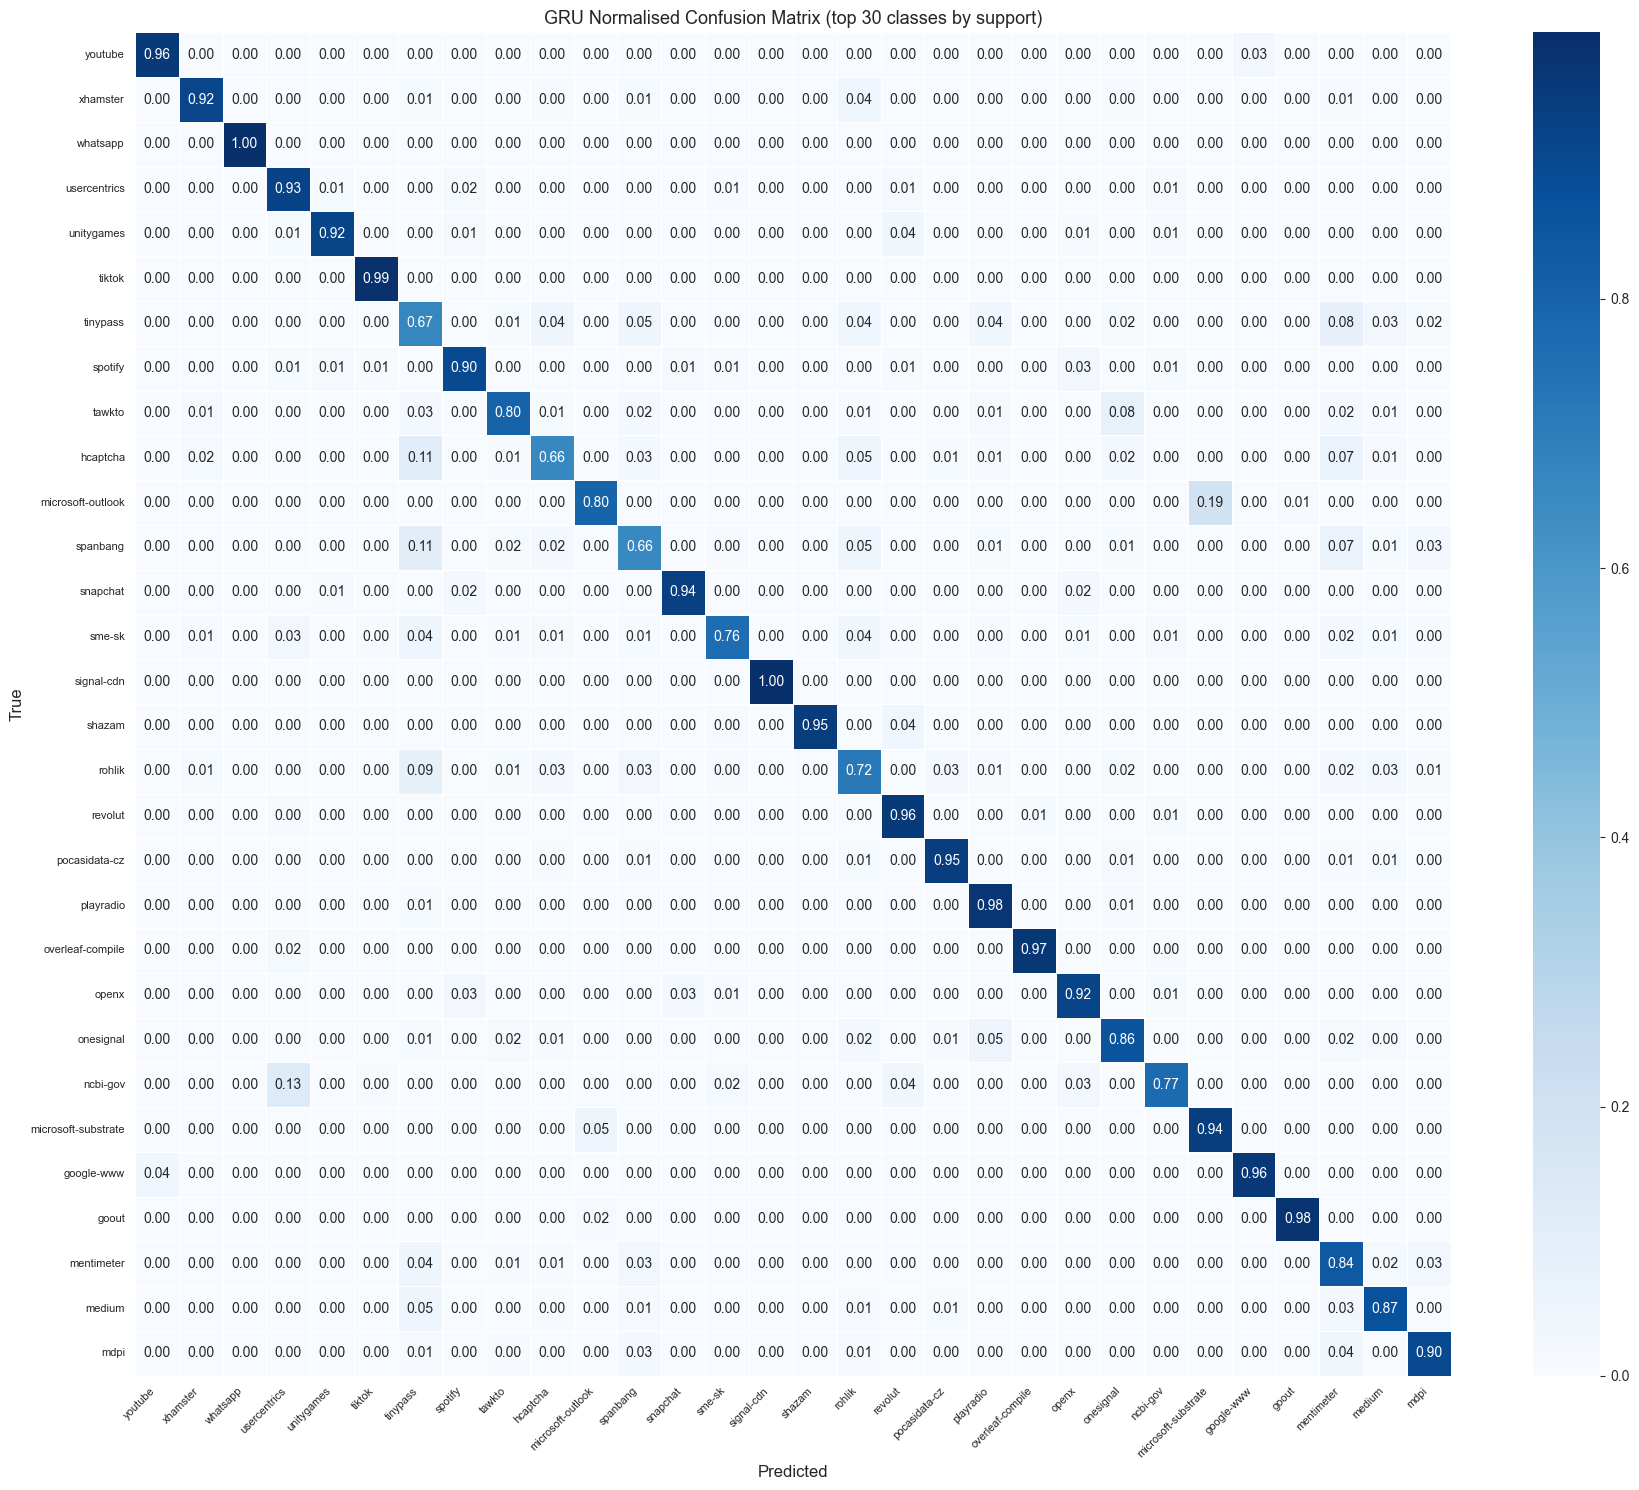

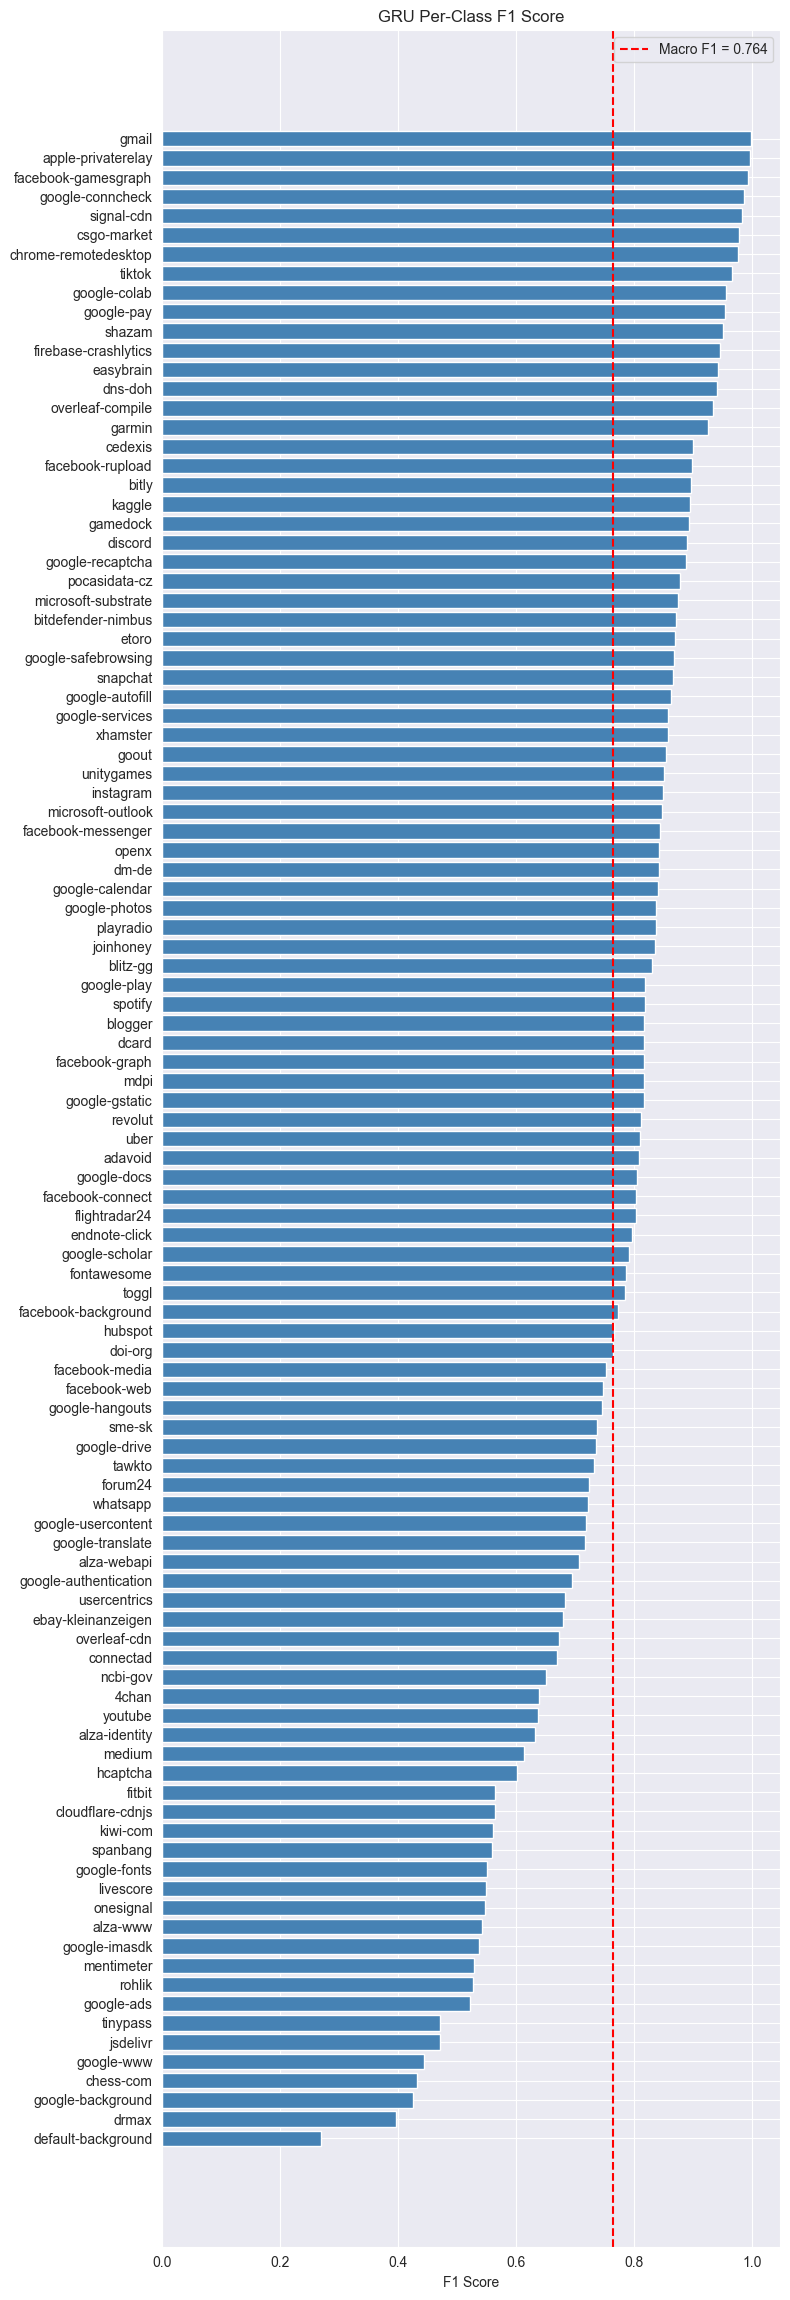

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report, confusion_matrix
)

gru_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for x, y_batch in val_loader:
        preds = gru_model(x.to(gru_model.device)).argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Decode integer labels back to class names if encoder is available
try:
    class_names = encoders_dict['label_encoder']['APP'].classes_
except (KeyError, AttributeError):
    class_names = None

# --- Summary metrics ---
acc         = accuracy_score(all_labels, all_preds)
macro_f1    = f1_score(all_labels, all_preds, average='macro',    zero_division=0)
weighted_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print("=" * 50)
print("GRU Test-Set Performance")
print("=" * 50)
print(f"  Accuracy       : {acc:.4f}")
print(f"  Macro F1       : {macro_f1:.4f}")
print(f"  Weighted F1    : {weighted_f1:.4f}")
print()

# --- Per-class report ---
print(classification_report(
    all_labels, all_preds,
    target_names=class_names,
    zero_division=0
))

# --- Confusion matrix (top-N classes by support for readability) ---
TOP_N = 30
counts = np.bincount(all_labels)
top_indices = np.argsort(counts)[-TOP_N:][::-1]

cm      = confusion_matrix(all_labels, all_preds, labels=top_indices)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

tick_labels = [class_names[i] for i in top_indices] if class_names is not None else top_indices

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=tick_labels, yticklabels=tick_labels,
    linewidths=0.4, ax=ax
)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title(f'GRU Normalised Confusion Matrix (top {TOP_N} classes by support)', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# --- Per-class F1 bar chart ---
per_class_f1  = f1_score(all_labels, all_preds, average=None, zero_division=0)
labels_for_plot = class_names if class_names is not None else np.arange(num_classes)
order = np.argsort(per_class_f1)

fig, ax = plt.subplots(figsize=(8, max(6, num_classes * 0.22)))
ax.barh(
    np.array(labels_for_plot)[order],
    per_class_f1[order],
    color='steelblue'
)
ax.axvline(macro_f1, color='red', linestyle='--', label=f'Macro F1 = {macro_f1:.3f}')
ax.set_xlabel('F1 Score')
ax.set_title('GRU Per-Class F1 Score')
ax.legend()
plt.tight_layout()
plt.show()

### Soft Voting Ensembler: LightGBM and GRU

In [ ]:
ppi_seq_only

In [42]:
import torch
import torch.nn.functional as F
import numpy as np

import torch
import torch.nn.functional as F
import numpy as np

def ensemble_predict_proba(lgb, gru, X_tabular, X_sequence, device='cuda'):
    # RF probabilities
    rf_probs = rf.predict_proba(X_tabular)  # shape (N, num_classes)

    # GRU probabilities
    gru.eval()
    with torch.no_grad():
        x = torch.tensor(X_sequence, dtype=torch.float32).to(device)
        logits = gru(x)
        gru_probs = F.softmax(logits, dim=1).cpu().numpy()

    # Average (equal weight)
    return (rf_probs + gru_probs) / 2

probs = ensemble_predict_proba(lgb, gru_model, tab_bm_X_test, seq_bm_X_test)
preds = probs.argmax(axis=1)

NameError: name 'lightgbm' is not defined